# **Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech**

- Nama: Muhammad Fikri Rouzan Ash Shidik
- Email: fikrirzn@gmail.com
- Id Dicoding: fikri_rouzan

## **Persiapan**

### **Menyiapkan Library yang Dibutuhkan**

In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
)

### **Menyiapkan Data yang Akan Digunakan**

In [2]:
df = pd.read_csv(
    "https://drive.google.com/uc?export=download&id=1LN3f51XynnKw4UaQrwW71eG9rBngiMiU"
)
df

,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,38,NaN,Travel_Frequently,1444,Human Resources,1,4,Other,1,...,2,80,1,7,2,3,6,2,1,2
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,...,1,80,0,15,2,1,1,0,0,0
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,...,3,80,3,18,2,4,10,0,2,7
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,...,4,80,1,23,2,4,20,4,4,8
4,5,40,NaN,Travel_Rarely,1194,Research & Development,2,4,Medical,1,...,2,80,3,20,2,3,5,3,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,1466,38,0.0,Travel_Rarely,168,Research & Development,1,3,Life Sciences,1,...,4,80,0,10,4,4,1,0,0,0
1466,1467,50,NaN,Travel_Rarely,813,Research & Development,17,5,Life Sciences,1,...,3,80,3,19,3,3,14,11,1,11
1467,1468,28,1.0,Travel_Rarely,1485,Research & Development,12,1,Life Sciences,1,...,4,80,0,1,4,2,1,1,0,0
1468,1469,40,0.0,Non-Travel,458,Research & Development,16,2,Life Sciences,1,...,2,80,1,6,0,3,4,2,0,0


**Insight:**
- Dataset berhasil dimuat dengan total 1.470 baris dan 35 kolom data karyawan.
- Kolom target `Attrition` berisi kombinasi data biner (1.0 dan 0.0) serta nilai kosong (`NaN`).

## **Data Understanding**

### **Struktur dan Informasi General Data**

In [3]:
print("Jumlah Baris dan Kolom:", df.shape)
print("")

df.info()

Jumlah Baris dan Kolom: (1470, 35)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmployeeId                1470 non-null   int64  
 1   Age                       1470 non-null   int64  
 2   Attrition                 1058 non-null   float64
 3   BusinessTravel            1470 non-null   object 
 4   DailyRate                 1470 non-null   int64  
 5   Department                1470 non-null   object 
 6   DistanceFromHome          1470 non-null   int64  
 7   Education                 1470 non-null   int64  
 8   EducationField            1470 non-null   object 
 9   EmployeeCount             1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   object 
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement            1

**Insight:**
- Dataset terdiri dari 1.470 baris dan 35 kolom. Seluruh 34 variabel fitur terisi secara penuh tanpa adanya data yang hilang.
- Kolom target `Attrition` memiliki 1.058 sampel berlabel, sedangkan 412 sampel sisanya bersifat unlabeled/missing.
- Struktur data terdiri dari 26 fitur numerik (int64), 8 fitur kategorikal (object), serta 1 variabel target (`Attrition` bertipe float64).

### **Ringkasan Statistik**

#### **Data Numerik**

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
EmployeeId,1470.0,735.500000,424.496761,1.0,368.25,735.5,1102.75,1470.0
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
Attrition,1058.0,0.169187,0.375094,0.0,0.00,0.0,0.00,1.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0


**Insight:**
- Fitur `EmployeeCount` dan `StandardHours` memiliki deviasi standar bernilai 0, artinya tidak memberikan variasi informasi sama sekali dan tidak berguna untuk model machine learning.
- Rata-rata variabel `Attrition` bernilai 0,169 (16,9%), yang menunjukkan bahwa kasus karyawan keluar merupakan porsi minoritas pada data terlabel.
- Fitur `MonthlyIncome` memiliki rentang yang sangat lebar dari minimum 1.009 hingga maksimum 19.999 (dengan median 4.919), mengindikasikan sebaran pendapatan yang cenderung miring ke kanan.

#### **Data Kategorikal**

In [5]:
df.describe(include="object").T

,count,unique,top,freq
BusinessTravel,1470,3,Travel_Rarely,1043
Department,1470,3,Research & Development,961
EducationField,1470,6,Life Sciences,606
Gender,1470,2,Male,882
JobRole,1470,9,Sales Executive,326
MaritalStatus,1470,3,Married,673
Over18,1470,1,Y,1470
OverTime,1470,2,No,1054


**Insight:**
- Fitur `Over18` hanya memiliki 1 nilai unik untuk seluruh 1.470 sampel karyawan, sehingga tidak memiliki daya pemisah dan siap untuk dieliminasi.
- Profil karyawan didominasi oleh kelompok yang jarang melakukan perjalanan dinas (1.043), berasal dari departemen Research & Development (961), berjenis kelamin pria (882), serta tidak mengambil lembur (1.054).
- Jumlah nilai unik pada seluruh variabel kategorikal tergolong wajar, sehingga aman dan efisien saat ditransformasi menggunakan One-Hot Encoding.

### **Memeriksa Missing Values dan Duplikasi Data**

In [6]:
print("Jumlah Baris Duplikat:", df.duplicated().sum())
print("\nJumlah Missing Values per Kolom:")
print(df.isna().sum()[df.isna().sum() > 0])

Jumlah Baris Duplikat: 0

Jumlah Missing Values per Kolom:
Attrition    412
dtype: int64


**Insight:**
- Dataset bersifat bersih tanpa adanya baris duplikat, mengindikasikan bahwa setiap sampel karyawan bernilai unik dan bebas dari redundansi data.
- Satu-satunya variabel yang memiliki missing value adalah kolom `Attrition` sebanyak 412 sampel.

### **Distribusi Variabel Target (Attrition)**

Distribusi Attrition (0.0 = No, 1.0 = Yes, NaN = Unlabeled):
Attrition
0.0    879
NaN    412
1.0    179
Name: count, dtype: int64



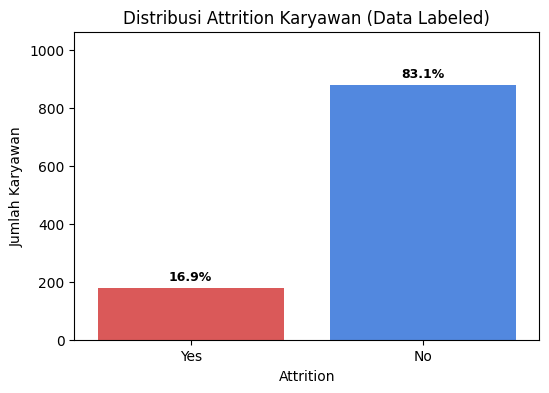

In [7]:
attrition_summary = df["Attrition"].value_counts(dropna=False)
print("Distribusi Attrition (0.0 = No, 1.0 = Yes, NaN = Unlabeled):")
print(attrition_summary)
print("")

df_labeled = df[df["Attrition"].notnull()].copy()
df_labeled["Attrition_Label"] = df_labeled["Attrition"].map({0.0: "No", 1.0: "Yes"})

plt.figure(figsize=(6, 4))

# Warna khusus
colors = {"Yes": "#ef4444", "No": "#3b82f6"}

ax = sns.countplot(
    data=df_labeled,
    x="Attrition_Label",
    hue="Attrition_Label",
    palette=colors,
    legend=False,
)

# Total seluruh data yang ter-label
total = len(df_labeled)

# Label persentase
for container in ax.containers:
    # Persentase untuk setiap bar
    labels = [f"{(bar.get_height() / total) * 100:.1f}%" for bar in container]
    ax.bar_label(container, labels=labels, padding=3, fontsize=9, fontweight="bold")

# Ruang tambahan di batas Y
plt.ylim(0, ax.get_ylim()[1] * 1.15)

plt.title("Distribusi Attrition Karyawan (Data Labeled)")
plt.xlabel("Attrition")
plt.ylabel("Jumlah Karyawan")
plt.show()

**Insight:**
- Dari total 1.058 sampel data berlabel, sebanyak 179 karyawan (16,9%) teridentifikasi mengalami attrition, sedangkan 879 karyawan (83,1%) memutuskan untuk bertahan.
- Tingkat attrition sebesar 16,9% berada di atas ambang batas toleransi ideal perusahaan (10%), mengonfirmasi adanya masalah retensi karyawan yang memerlukan intervensi penanganan proaktif.
- Terdapat ketidakseimbangan distribusi kelas pada variabel target dengan rasio sekitar 83:17.

### **Analisis Attrition**

#### **Berdasarkan Faktor Beban Kerja (OverTime & BusinessTravel)**

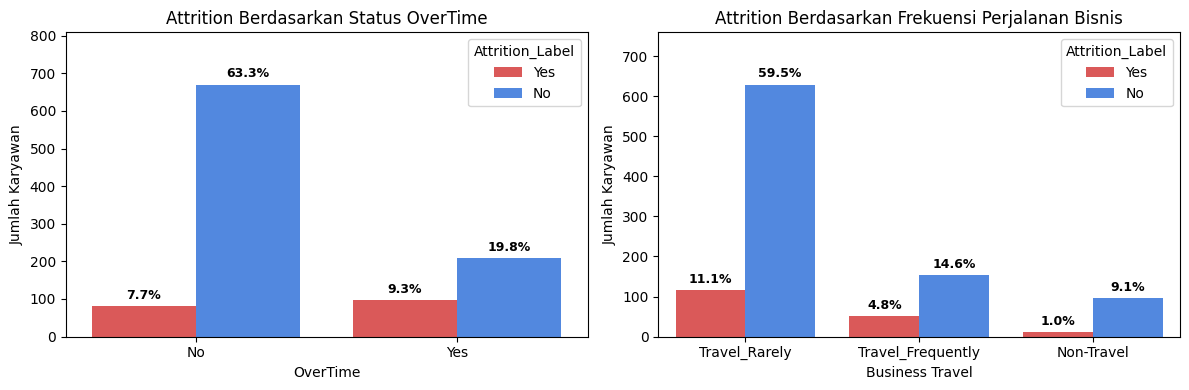

In [8]:
# Total seluruh data yang ter-label
total = len(df_labeled)

# Warna khusus
colors = {"Yes": "#ef4444", "No": "#3b82f6"}

plt.figure(figsize=(12, 4))

# Subplot 1: OverTime
ax1 = plt.subplot(1, 2, 1)
sns.countplot(data=df_labeled, x="OverTime", hue="Attrition_Label", palette=colors)
plt.title("Attrition Berdasarkan Status OverTime")
plt.xlabel("OverTime")
plt.ylabel("Jumlah Karyawan")

# Label persentase
for container in ax1.containers:
    labels = [
        f"{(bar.get_height() / total) * 100:.1f}%" if bar.get_height() > 0 else ""
        for bar in container
    ]
    ax1.bar_label(container, labels=labels, padding=3, fontsize=9, fontweight="bold")
ax1.set_ylim(0, ax1.get_ylim()[1] * 1.15)

# Subplot 2: BusinessTravel
ax2 = plt.subplot(1, 2, 2)
sns.countplot(
    data=df_labeled, x="BusinessTravel", hue="Attrition_Label", palette=colors
)
plt.title("Attrition Berdasarkan Frekuensi Perjalanan Bisnis")
plt.xlabel("Business Travel")
plt.ylabel("Jumlah Karyawan")

# Label persentase
for container in ax2.containers:
    labels = [
        f"{(bar.get_height() / total) * 100:.1f}%" if bar.get_height() > 0 else ""
        for bar in container
    ]
    ax2.bar_label(container, labels=labels, padding=3, fontsize=9, fontweight="bold")
ax2.set_ylim(0, ax2.get_ylim()[1] * 1.15)

plt.tight_layout()
plt.show()

**Insight:**
- **Status Lembur:** Karyawan yang mengambil lembur memiliki tingkat attrition jauh lebih tinggi. Di dalam kelompok karyawan yang lembur, sebanyak 32,0% (berkontribusi 9.3% dari total data) memutuskan keluar, jauh melampaui kelompok yang tidak lembur yang hanya 10,8% (berkontribusi 7.7% dari total data). Hal ini mengonfirmasi bahwa beban kerja berlebih merupakan salah satu pemicu utama attrition.
- **Frekuensi Perjalanan Bisnis:** Tingkat attrition berbanding lurus dengan tingginya frekuensi perjalanan dinas. Kelompok yang sering bepergian (`Travel_Frequently`) mencatatkan proporsi attrition tertinggi di kelompoknya sebesar 24,7% (berkontribusi 4.8% dari total data), disusul oleh `Travel_Rarely` sebesar 15,7% (11.1% dari total data), dan `Non-Travel` sebesar 9,9% (1.0% dari total data). Mobilitas tinggi yang melelahkan turut menjadi pendorong signifikan keputusan pengunduran diri.

#### **Berdasarkan Departemen dan Peran Pekerjaan**

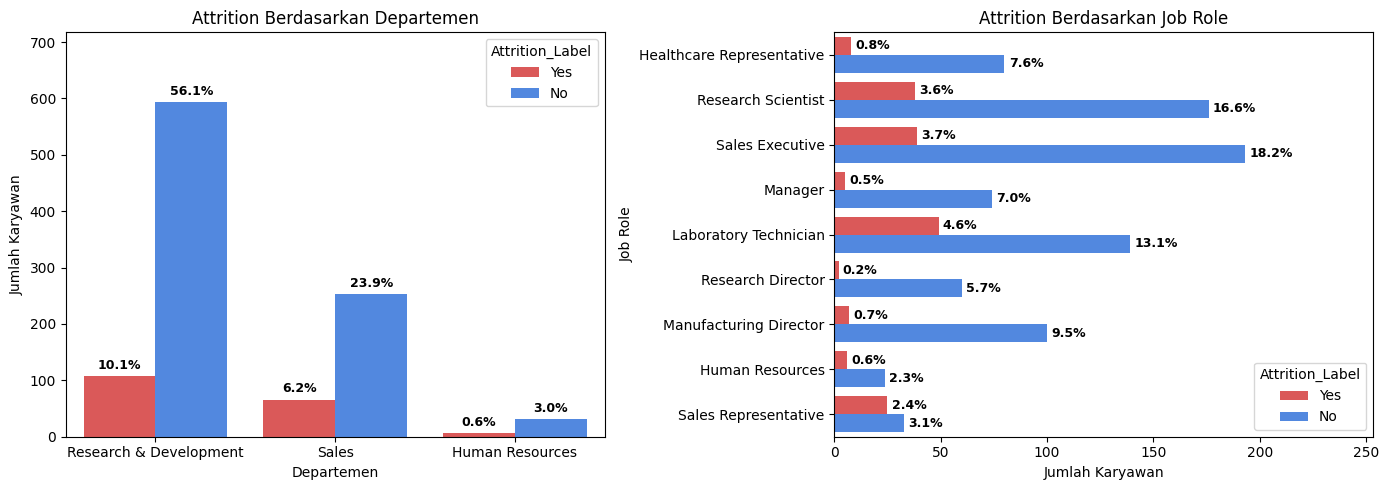

In [9]:
# Total seluruh data yang ter-label
total = len(df_labeled)

# Warna khusus
colors = {"Yes": "#ef4444", "No": "#3b82f6"}

plt.figure(figsize=(14, 5))

# Subplot 1: Department
ax1 = plt.subplot(1, 2, 1)
sns.countplot(data=df_labeled, x="Department", hue="Attrition_Label", palette=colors)
plt.title("Attrition Berdasarkan Departemen")
plt.xlabel("Departemen")
plt.ylabel("Jumlah Karyawan")

# Label persentase
for container in ax1.containers:
    labels = [
        f"{(bar.get_height() / total) * 100:.1f}%" if bar.get_height() > 0 else ""
        for bar in container
    ]
    ax1.bar_label(container, labels=labels, padding=3, fontsize=9, fontweight="bold")
ax1.set_ylim(0, ax1.get_ylim()[1] * 1.15)

# Subplot 2: Job Role
ax2 = plt.subplot(1, 2, 2)
sns.countplot(data=df_labeled, y="JobRole", hue="Attrition_Label", palette=colors)
plt.title("Attrition Berdasarkan Job Role")
plt.xlabel("Jumlah Karyawan")
plt.ylabel("Job Role")

# Label persentase
for container in ax2.containers:
    labels = [
        f"{(bar.get_width() / total) * 100:.1f}%" if bar.get_width() > 0 else ""
        for bar in container
    ]
    ax2.bar_label(container, labels=labels, padding=3, fontsize=9, fontweight="bold")
ax2.set_xlim(0, ax2.get_xlim()[1] * 1.25)

plt.tight_layout()
plt.show()

**Insight:**
- **Departemen:** Departemen Sales mencatatkan attrition rate tertinggi di kelompoknya sebesar 20,6% (berkontribusi 6.2% dari total data), disusul oleh Human Resources sebesar 16,7% (0.6% dari total data) dan Research & Development sebesar 15,3% (10.1% dari total data).
- **Peran Pekerjaan:** Peran pekerjaan Sales Representative merupakan posisi paling kritis dengan tingkat attrition ekstrem mencapai 43,6% di internal perannya (2.4% dari total data), diikuti oleh Laboratory Technician sebesar 26,0% (4.6% dari total data) dan Human Resources sebesar 20,7% (0.6% dari total data). Sebaliknya, posisi manajerial senior seperti Research Director (3,4%) dan Manager (6,7%) memiliki tingkat retensi yang sangat stabil.

#### **Berdasarkan Usia, Pendapatan, dan Work Life Balance**

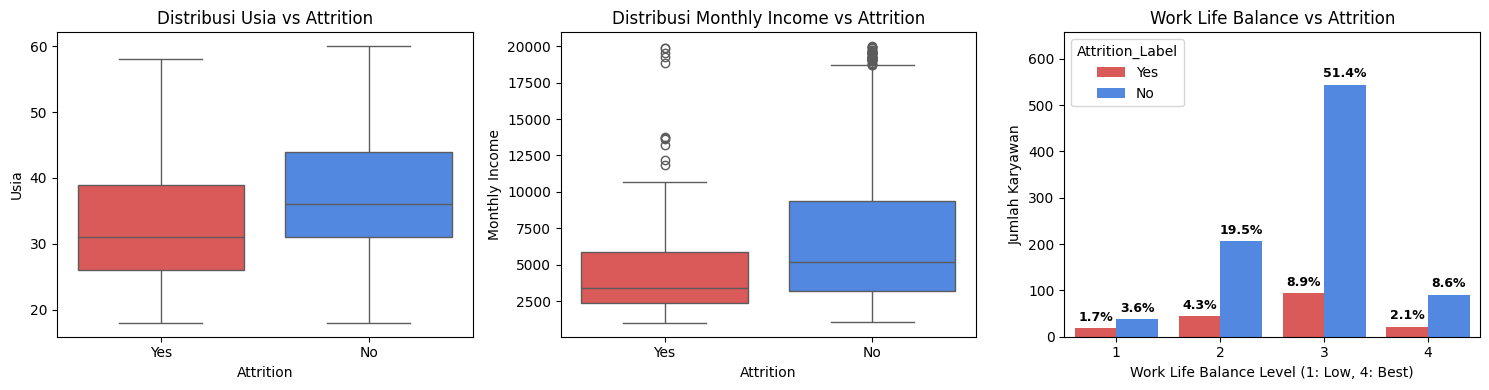

In [10]:
# Total seluruh data yang ter-label
total = len(df_labeled)

# Warna khusus
colors = {"Yes": "#ef4444", "No": "#3b82f6"}

plt.figure(figsize=(15, 4))

# Subplot 1
plt.subplot(1, 3, 1)
sns.boxplot(
    data=df_labeled, x="Attrition_Label", y="Age", hue="Attrition_Label", palette=colors
)
plt.title("Distribusi Usia vs Attrition")
plt.xlabel("Attrition")
plt.ylabel("Usia")

# Subplot 2
plt.subplot(1, 3, 2)
sns.boxplot(
    data=df_labeled,
    x="Attrition_Label",
    y="MonthlyIncome",
    hue="Attrition_Label",
    palette=colors,
)
plt.title("Distribusi Monthly Income vs Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")

# Subplot 3
ax3 = plt.subplot(1, 3, 3)
sns.countplot(
    data=df_labeled, x="WorkLifeBalance", hue="Attrition_Label", palette=colors
)
plt.title("Work Life Balance vs Attrition")
plt.xlabel("Work Life Balance Level (1: Low, 4: Best)")
plt.ylabel("Jumlah Karyawan")

# Label persentase
for container in ax3.containers:
    labels = [
        f"{(bar.get_height() / total) * 100:.1f}%" if bar.get_height() > 0 else ""
        for bar in container
    ]
    ax3.bar_label(container, labels=labels, padding=3, fontsize=9, fontweight="bold")
ax3.set_ylim(0, ax3.get_ylim()[1] * 1.15)

plt.tight_layout()
plt.show()

**Insight:**
- **Usia:** Median usia karyawan yang mengalami attrition adalah 31 tahun, lebih muda dibandingkan karyawan yang memilih bertahan (36 tahun). Hal ini menunjukkan bahwa karyawan usia muda atau dalam tahap awal karir memiliki kecenderungan lebih tinggi untuk berpindah pekerjaan.
- **Monthly Income:** Karyawan yang mengundurkan diri memiliki median pendapatan bulanan yang jauh lebih rendah, yaitu 3.388, dibandingkan karyawan yang bertahan (5.210). Ketimpangan pendapatan ini mengonfirmasi bahwa kompensasi finansial merupakan faktor retensi yang sangat mendasar.
- **Work Life Balance:** Karyawan dengan tingkat Work Life Balance terendah (skor 1) mencatatkan attrition rate tertinggi di kelompoknya sebesar 32,1% (berkontribusi 1.7% dari total data), jauh melampaui rata-rata attrition keseluruhan. Temuan ini menegaskan pentingnya keseimbangan kehidupan kerja untuk menekan angka pengunduran diri.

## **Data Preparation / Preprocessing**

### **Menghapus Kolom yang Tidak Relevan dan Konstan**

In [11]:
drop_cols = ["EmployeeId", "EmployeeCount", "Over18", "StandardHours"]
df_clean = df.drop(columns=drop_cols)

print("Jumlah kolom awal:", df.shape[1])
print("Jumlah kolom setelah dropping:", df_clean.shape[1])

Jumlah kolom awal: 35
Jumlah kolom setelah dropping: 31


**Insight:**
- Sebanyak 4 variabel yang bersifat identitas unik (`EmployeeId`) maupun variabel bernilai konstan (`EmployeeCount`, `Over18`, `StandardHours`) dieliminasi karena tidak memberikan informasi acuan dalam memprediksi attrition.
- Eliminasi ini berhasil mereduksi jumlah atribut data dari 35 menjadi 31 kolom.

### **Memisahkan Data Labeled dan Data Unlabeled**

In [12]:
# Memisahkan data yang sudah memiliki label Attrition dan data yang unlabeled
df_labeled = df_clean[df_clean["Attrition"].notnull()].copy()
df_unlabeled = df_clean[df_clean["Attrition"].isnull()].copy()

# Mengubah tipe data Attrition dari float menjadi integer
df_labeled["Attrition"] = df_labeled["Attrition"].astype(int)

print("Jumlah data Labeled (untuk Training & Validation):", df_labeled.shape)
print("Jumlah data Unlabeled (untuk Inferensi):", df_unlabeled.shape)

Jumlah data Labeled (untuk Training & Validation): (1058, 31)
Jumlah data Unlabeled (untuk Inferensi): (412, 31)


**Insight:**
- Data berhasil dipisahkan menjadi 1.058 sampel data berlabel yang difokuskan untuk pelatihan serta validasi model, dan 412 sampel data tanpa label yang disiapkan sebagai target penerapan prediksi.
- Konversi kolom `Attrition` dari float menjadi integer memastikan variabel target berada dalam format biner yang sesuai dengan standar algoritma klasifikasi machine learning.

### **Memisahkan Fitur (X) dan Target (y)**

In [13]:
X = df_labeled.drop(columns=["Attrition"])
y = df_labeled["Attrition"]

print("Dimensi Fitur (X):", X.shape)
print("Dimensi Target (y):", y.shape)

Dimensi Fitur (X): (1058, 30)
Dimensi Target (y): (1058,)


**Insight:**
- Data berlabel berhasil dipisahkan menjadi matriks fitur (X) yang memuat 30 variabel prediktor dan vektor target (y) yang berisi label `Attrition` untuk 1.058 sampel karyawan.
- Kesesuaian jumlah baris pada fitur dan target mengonfirmasi bahwa pasangan data input-output telah terstruktur secara presisi dan siap masuk ke tahap pembagian dataset maupun pelatihan model.

### **Membagi Data Menjadi Training dan Testing**

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Jumlah sampel Training:", X_train.shape[0])
print("Jumlah sampel Testing:", X_test.shape[0])
print("\nProporsi Target pada Training:\n", y_train.value_counts(normalize=True))
print("\nProporsi Target pada Testing:\n", y_test.value_counts(normalize=True))

Jumlah sampel Training: 846
Jumlah sampel Testing: 212

Proporsi Target pada Training:
 Attrition
0    0.830969
1    0.169031
Name: proportion, dtype: float64

Proporsi Target pada Testing:
 Attrition
0    0.830189
1    0.169811
Name: proportion, dtype: float64


**Insight:**
- Dataset berhasil dipisahkan menjadi 846 sampel data training (80%) untuk proses pelatihan model dan 212 sampel data testing (20%) yang dialokasikan khusus untuk pengujian performa secara independen.
- Penerapan stratified split terbukti menjaga rasio variabel target `Attrition` tetap seimbang dan konsisten antara data training dan data testing.

### **Pipeline Preprocessing Fitur Numerik dan Kategorikal**

In [15]:
# Mengidentifikasi daftar kolom berdasarkan tipe data
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

# Membangun ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        (
            "cat",
            OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False),
            cat_cols,
        ),
    ]
)

print("Daftar Fitur Numerik:", len(num_cols), "fitur")
print("Daftar Fitur Kategorikal:", len(cat_cols), "fitur")

Daftar Fitur Numerik: 23 fitur
Daftar Fitur Kategorikal: 7 fitur


**Insight:**
- Dari total 30 variabel prediktor, dataset berhasil dikelompokkan secara tepat menjadi 23 fitur numerik dan 7 fitur kategorikal.
- Seluruh 23 fitur numerik disamakan skalanya.
- Sebanyak 7 fitur kategorikal diubah menjadi format biner (0/1) agar dapat dipahami oleh algoritma machine learning.

### **Preprocessing pada Data Training dan Testing**

In [16]:
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

# Mengambil nama fitur hasil encoding
feature_names_out = preprocessor.get_feature_names_out()

print("Bentuk X_train setelah preprocessing:", X_train_prep.shape)
print("Bentuk X_test setelah preprocessing:", X_test_prep.shape)

Bentuk X_train setelah preprocessing: (846, 44)
Bentuk X_test setelah preprocessing: (212, 44)


**Insight:**
- Penggunaan `fit_transform` khusus pada data training dan `transform` saja pada data testing memastikan parameter transformasi hanya dipelajari dari data latih, sehingga evaluasi model nantinya tetap independen dan obyektif.
- Proses preprocessing berhasil mengubah dataset dari 30 fitur awal menjadi 44 fitur terstruktur. Penambahan jumlah kolom ini terjadi akibat ekspansi One-Hot Encoding pada variabel kategorikal, sementara jumlah baris sampel tetap konsisten.

## **Modeling**

### **Logistic Regression**

In [17]:
model_lr = LogisticRegression(random_state=42, max_iter=1000, class_weight="balanced")
model_lr.fit(X_train_prep, y_train)

y_pred_lr = model_lr.predict(X_test_prep)
y_prob_lr = model_lr.predict_proba(X_test_prep)[:, 1]

print("Model Logistic Regression berhasil dilatih.")

Model Logistic Regression berhasil dilatih.


**Insight:**
- Pelatihan model baseline linier yang memanfaatkan penyeimbangan bobot kelas untuk meningkatkan sensitivitas terhadap pola karyawan berisiko attrition.

### **Random Forest**

In [18]:
model_rf = RandomForestClassifier(
    n_estimators=100, random_state=42, class_weight="balanced"
)
model_rf.fit(X_train_prep, y_train)

y_pred_rf = model_rf.predict(X_test_prep)
y_prob_rf = model_rf.predict_proba(X_test_prep)[:, 1]

print("Model Random Forest Classifier berhasil dilatih.")

Model Random Forest Classifier berhasil dilatih.


**Insight:**
- Pelatihan model ensemble berbasis gabungan 100 decision trees secara paralel yang dikombinasikan dengan penyesuaian bobot kelas untuk menangkap variasi data yang kompleks.

### **Gradient Boosting**

In [19]:
model_gb = GradientBoostingClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42
)
model_gb.fit(X_train_prep, y_train)

y_pred_gb = model_gb.predict(X_test_prep)
y_prob_gb = model_gb.predict_proba(X_test_prep)[:, 1]

print("Model Gradient Boosting Classifier berhasil dilatih.")

Model Gradient Boosting Classifier berhasil dilatih.


**Insight:**
- Pelatihan model ensemble berbasis sequential boosting yang secara berkelanjutan mengoreksi kesalahan prediksi dari pohon-pohon keputusan sebelumnya.

### **Support Vector Machine (SVM)**

In [20]:
model_svm = SVC(
    kernel="rbf", C=1.0, probability=True, random_state=42, class_weight="balanced"
)
model_svm.fit(X_train_prep, y_train)

y_pred_svm = model_svm.predict(X_test_prep)
y_prob_svm = model_svm.predict_proba(X_test_prep)[:, 1]

print("Model Support Vector Machine (SVM) berhasil dilatih.")

Model Support Vector Machine (SVM) berhasil dilatih.


**Insight:**
- Pelatihan model dengan pemisahan pola non-linier (RBF kernel) yang dilengkapi kalkulasi probabilitas serta penyeimbangan bobot kelas untuk pembentukan batas keputusan yang optimal.

## **Evaluation**

### **Tabel Komparasi Evaluasi Performa Seluruh Model**

In [21]:
eval_results = []

models_dict = {
    "Logistic Regression": model_lr,
    "Random Forest": model_rf,
    "Gradient Boosting": model_gb,
    "Support Vector Machine": model_svm,
}

for name, model in models_dict.items():
    y_pred = model.predict(X_test_prep)
    y_prob = model.predict_proba(X_test_prep)[:, 1]

    eval_results.append(
        {
            "Model": name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1-Score": f1_score(y_test, y_pred),
            "ROC-AUC": roc_auc_score(y_test, y_prob),
        }
    )

eval_df = pd.DataFrame(eval_results).sort_values(by="ROC-AUC", ascending=False)
eval_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
3,Support Vector Machine,0.806604,0.457627,0.750000,0.568421,0.863479
1,Random Forest,0.839623,0.666667,0.111111,0.190476,0.813210
0,Logistic Regression,0.735849,0.364865,0.750000,0.490909,0.812658
2,Gradient Boosting,0.858491,0.666667,0.333333,0.444444,0.790878


**Insight:**
- **Prioritas Metrik Bisnis:** Dalam studi kasus HR Attrition, dampak kerugian akibat False Negative (karyawan yang diprediksi bertahan padahal sebenarnya hendak mundur) jauh lebih berisiko dibandingkan False Positive. Oleh karena itu, Recall dan ROC-AUC menjadi metrik evaluasi utama.
- **Model Terbaik:** SVM terbukti sebagai model paling optimal secara keseluruhan. Meskipun nilai Accuracy-nya (80,66%) sedikit di bawah Gradient Boosting, SVM berhasil mencatatkan Recall tertinggi (75,00%) (sejajar dengan Logistic Regression), ROC-AUC tertinggi (0,8635), serta keseimbangan keseimbangan performa F1-Score terbaik (0,5684).
- **Keterbatasan Model Ensemble:** Meskipun memiliki Accuracy tinggi (83,96% & 85,85%), kedua algoritma ini gagal menangani ketidakseimbangan kelas dengan baik. Hal ini terlihat dari nilai Recall yang sangat rendah (11,11% pada Random Forest dan 33,33% pada Gradient Boosting), yang berarti mayoritas karyawan berisiko keluar justru luput dari sistem.
- **Model Baseline:** Mampu menghasilkan Recall yang setara dengan SVM (75,00%), namun memproduksi False Positive yang jauh lebih tinggi sehingga nilai Accuracy (73,58%) dan Precision (36,49%)-nya menjadi yang terendah di antara semua model.

### **Confusion Matrix untuk Setiap Model**

#### **Logistic Regression**

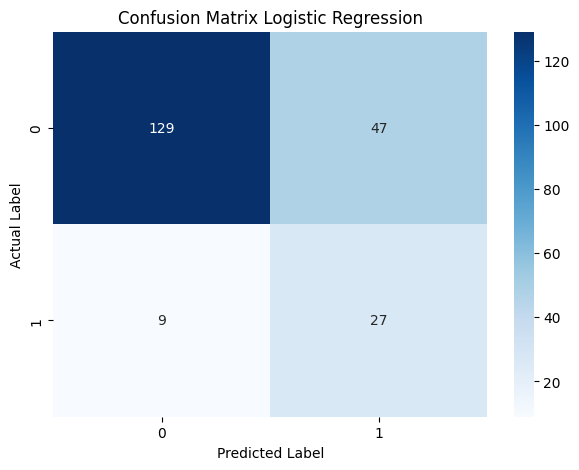

In [22]:
y_pred_lr = model_lr.predict(X_test_prep)
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

**Insight:**
- **True Positives (TP): 27** | Model berhasil memprediksi dengan tepat 27 karyawan yang benar-benar mengalami attrition.
- **False Negatives (FN): 9** | Terdapat 9 karyawan yang sebenarnya mengundurkan diri, namun diprediksi akan bertahan.
- **False Positives (FP): 47** | Model memberikan peringatan palsu pada 47 karyawan yang sebenarnya tetap bertahan.
- **True Negatives (TN): 129** | Model tepat memprediksi 129 karyawan yang bertahan di perusahaan.

#### **Random Forest**

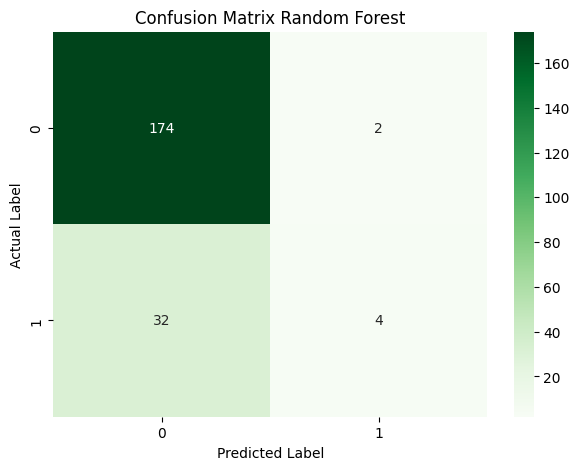

In [23]:
y_pred_rf = model_rf.predict(X_test_prep)
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

**Insight:**
- **True Positives (TP): 4** | Model hanya mampu mendeteksi 4 dari total 36 karyawan yang berisiko keluar.
- **False Negatives (FN): 32** | Risiko tinggi: 32 karyawan (88,9% dari total attrition) luput dari deteksi model.
- **False Positives (FP): 2** | Model hanya memberikan 2 peringatan palsu pada karyawan yang sebenarnya bertahan.
- **True Negatives (TN): 174** | Model sangat dominan dan tepat menebak 174 karyawan yang bertahan.

#### **Gradient Boosting**

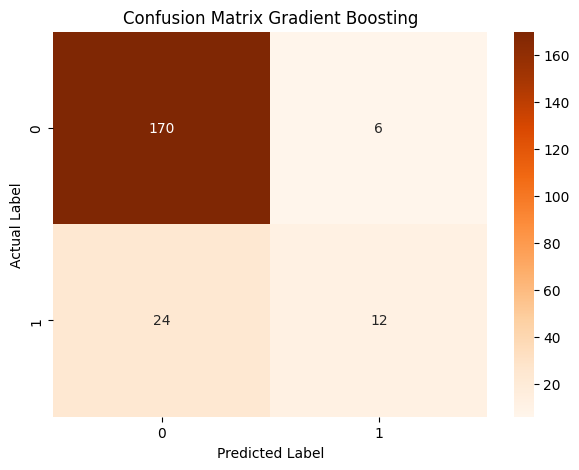

In [24]:
y_pred_gb = model_gb.predict(X_test_prep)
cm_gb = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_gb, annot=True, fmt="d", cmap="Oranges")
plt.title("Confusion Matrix Gradient Boosting")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

**Insight:**
- **True Positives (TP): 12** | Model berhasil mendeteksi 12 dari total 36 karyawan yang berisiko attrition.
- **False Negatives (FN): 24** | Masih terdapat 24 karyawan yang terlewat dari sistem deteksi.
- **False Positives (FP): 6** | Model memberikan 6 peringatan palsu pada karyawan yang sebenarnya tidak keluar.
- **True Negatives (TN): 170** | Model berhasil mengidentifikasi 170 karyawan yang bertahan dengan akurat.

#### **Support Vector Machine (SVM)**

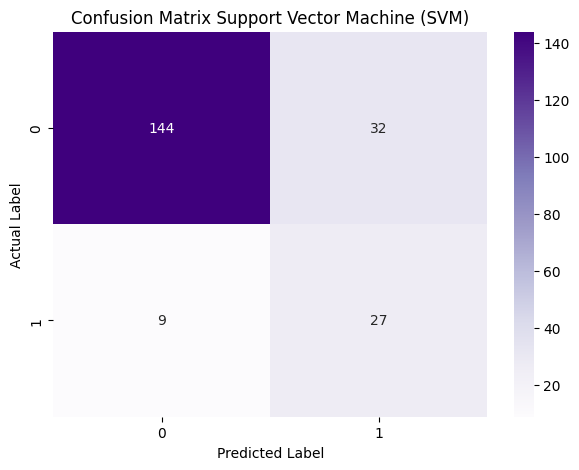

In [25]:
y_pred_svm = model_svm.predict(X_test_prep)
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Purples")
plt.title("Confusion Matrix Support Vector Machine (SVM)")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

**Insight:**
- **True Positives (TP): 27** | Model berhasil mendeteksi 27 dari 36 karyawan yang berisiko attrition.
- **False Negatives (FN): 9** | Mampu menekan tingkat False Negative sejajar dengan Logistic Regression (hanya 9 karyawan yang terlewat).
- **False Positives (FP): 32** | Menghasilkan kesalahan alarm palsu yang lebih sedikit dibandingkan Logistic Regression (32 vs 47).
- **True Negatives (TN): 144** | Mengidentifikasi 144 karyawan yang bertahan dengan tepat.

### **Kurva ROC-AUC untuk Komparasi Model**

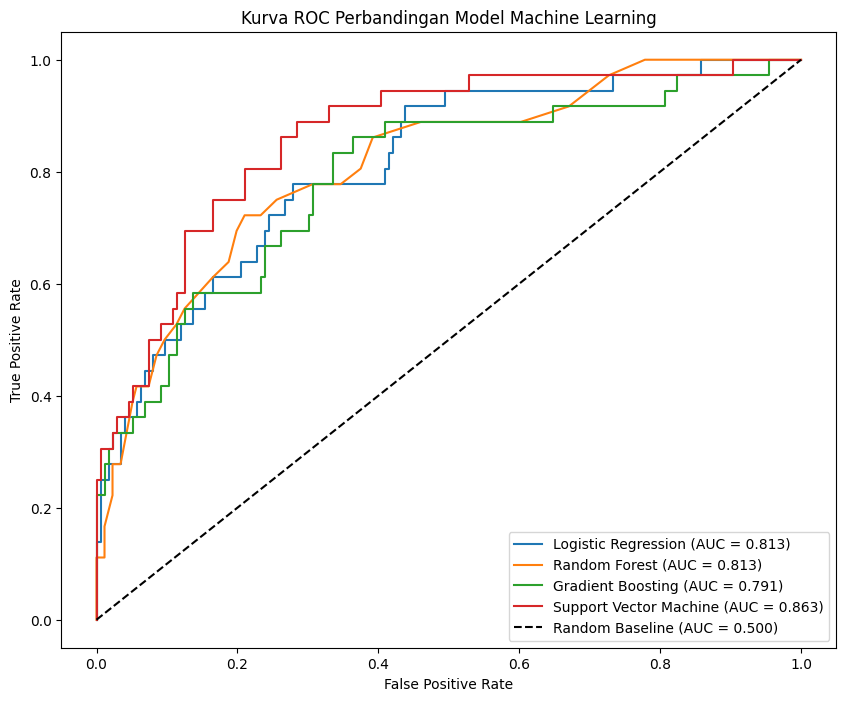

In [26]:
plt.figure(figsize=(10, 8))

for name, model in models_dict.items():
    y_prob = model.predict_proba(X_test_prep)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_val:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random Baseline (AUC = 0.500)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Kurva ROC Perbandingan Model Machine Learning")
plt.legend()
plt.show()

**Insight:**
- **Model Terbaik:** SVM (garis merah) mencatatkan nilai AUC tertinggi sebesar 0,863 dan kurvanya mendominasi area atas. Ini menunjukkan SVM memiliki kemampuan diskriminasi terbaik dalam memisahkan karyawan berisiko attrition dan karyawan yang bertahan.
- **Performa Seimbang:** Kedua model menghasilkan performa yang identik dengan nilai AUC 0,813, membuktikan keduanya cukup andal dan berada jauh di atas garis random baseline (0,500).
- **Performa Terendah:** Dengan nilai AUC 0,791, Gradient Boosting menjadi model dengan daya pemisahan paling terbatas dibandingkan tiga model lainnya dalam studi kasus ini.

### **Fitur Paling Berpengaruh terhadap Attrition**

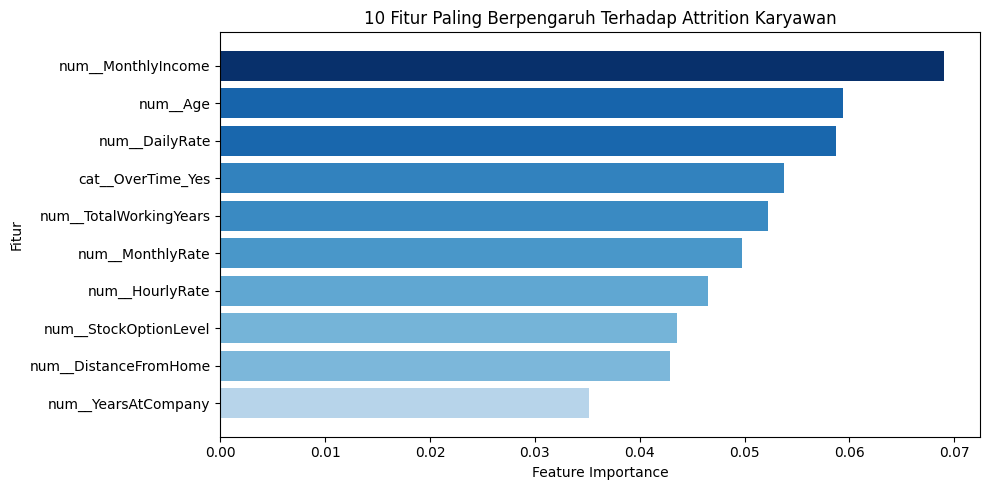

In [27]:
# Mengambil 10 fitur teratas dari model Random Forest
rf_importances = (
    pd.DataFrame(
        {"Feature": feature_names_out, "Importance": model_rf.feature_importances_}
    )
    .sort_values(by="Importance", ascending=True)
    .tail(10)
)

# Gradasi warna berdasarkan nilai Importance
norm_importance = (
    rf_importances["Importance"] - rf_importances["Importance"].min()
) / (rf_importances["Importance"].max() - rf_importances["Importance"].min())
colors = plt.cm.Blues(0.3 + 0.7 * norm_importance)

plt.figure(figsize=(10, 5))
plt.barh(rf_importances["Feature"], rf_importances["Importance"], color=colors)
plt.title("10 Fitur Paling Berpengaruh Terhadap Attrition Karyawan")
plt.xlabel("Feature Importance")
plt.ylabel("Fitur")
plt.tight_layout()
plt.show()

**Insight:**
- **Faktor Finansial & Kompensasi:** `MonthlyIncome` menduduki posisi teratas sebagai pemicu utama attrition. Faktor finansial lainnya seperti `DailyRate`, `MonthlyRate`, `HourlyRate`, dan `StockOptionLevel` turut mendominasi daftar. Hal ini menunjukkan bahwa struktur gaji dan insentif keuangan memegang peranan krusial sebagai pilar retensi karyawan di perusahaan.
- **Faktor Demografi & Pengalaman:** Usia (`Age`) serta total pengalaman kerja (`TotalWorkingYears`) menjadi prediktor penting dalam attrition. Temuan ini mengindikasikan bahwa tingkat kematangan usia dan akumulasi pengalaman kerja sangat memengaruhi loyalitas, di mana karyawan dengan profil yang lebih muda atau pengalaman lebih singkat memiliki kecenderungan berpindah tempat kerja yang lebih tinggi.
- **Beban Kerja & Aksesibilitas Operasional:** Status lembur (`OverTime_Yes`) muncul sebagai faktor penentu yang sangat signifikan, yang mengindikasikan bahwa beban kerja berlebih dapat memicu burnout dan mendorong keputusan karyawan untuk keluar. Selain itu, faktor lingkungan dan aksesibilitas seperti jarak tempat kerja (`DistanceFromHome`) serta masa kerja di perusahaan (`YearsAtCompany`) turut melengkapi rangkaian faktor risiko utama ini.

## **Tahap Lanjutan**

### **Menyimpan Model dan Preprocessor**

In [28]:
joblib.dump(preprocessor, "preprocessor.joblib")
joblib.dump(model_svm, "model_svm.joblib")

print("Model SVM dan Preprocessor berhasil disimpan ke format .joblib")

Model SVM dan Preprocessor berhasil disimpan ke format .joblib


**Insight:**
- Seluruh aturan pemrosesan data dan model prediksi telah tersimpan dengan aman.

### **Inferensi pada Data Unlabeled (412 Karyawan)**

In [29]:
# Memuat kembali preprocessor dan model terlatih
loaded_preprocessor = joblib.load("preprocessor.joblib")
loaded_model = joblib.load("model_svm.joblib")

# Mempersiapkan fitur dari data unlabeled
X_unlabeled = df_unlabeled.drop(columns=["Attrition"])
X_unlabeled_prep = loaded_preprocessor.transform(X_unlabeled)

# Prediksi status dan skor risiko attrition
df_unlabeled_res = df[df["Attrition"].isnull()].copy()
df_unlabeled_res["Predicted_Attrition"] = loaded_model.predict(X_unlabeled_prep)
df_unlabeled_res["Attrition_Risk_Score"] = np.round(
    loaded_model.predict_proba(X_unlabeled_prep)[:, 1], 4
)

# Hasil prediksi 5 karyawan pertama
print("Ringkasan Prediksi Data Unlabeled:")
print(
    df_unlabeled_res["Predicted_Attrition"]
    .value_counts()
    .rename({0: "Diprediksi Bertahan", 1: "Diprediksi Out"})
)
print("\nContoh Hasil Prediksi Risiko Karyawan:")
df_unlabeled_res[
    [
        "EmployeeId",
        "Age",
        "Department",
        "JobRole",
        "Predicted_Attrition",
        "Attrition_Risk_Score",
    ]
].head()

Ringkasan Prediksi Data Unlabeled:
Predicted_Attrition
Diprediksi Bertahan    322
Diprediksi Out          90
Name: count, dtype: int64

Contoh Hasil Prediksi Risiko Karyawan:


,EmployeeId,Age,Department,JobRole,Predicted_Attrition,Attrition_Risk_Score
0,1,38,Human Resources,Human Resources,0,0.2047
4,5,40,Research & Development,Research Scientist,0,0.0088
5,6,29,Human Resources,Human Resources,0,0.2021
12,13,47,Sales,Sales Executive,0,0.0867
18,19,25,Research & Development,Manufacturing Director,0,0.0234


**Insight:**
- Sebanyak 322 karyawan (78,2%) diprediksi stabil dan memilih tetap bertahan di perusahaan.
- Terdapat 90 karyawan (21,8%) yang terprediksi berpotensi keluar, sehingga membutuhkan perhatian dan penanganan dari tim HR secara proaktif.
- Kehadiran nilai Attrition Risk Score mempermudah perusahaan untuk menyaring dan memprioritaskan karyawan mana yang paling mendesak untuk diberikan program retensi sebelum mereka benar-benar memutuskan untuk keluar.